# AI4I 2020 — Exploratory Data Analysis

**Project #1 — Industrial EDA + Dashboard**  
*Author: Win • B.Eng. Automation, Robotics & AI, Khon Kaen University*


## 1. Setup & Imports


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import load_ai4i, save_fig, SENSOR_COLS, FAILURE_COLS, DATA_PROCESSED

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

print('Project root:', PROJECT_ROOT)


Project root: c:\Project_DA\industrial-eda-dashboard


## 2. Load Data


In [2]:
df = load_ai4i()
print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')
df.head()


Loaded 10,000 rows × 14 columns


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Data Overview


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [4]:
missing = df.isna().sum()
dupes = df.duplicated().sum()
print(f'Missing values per column:\n{missing[missing > 0] if missing.any() else "  none"}')
print(f'\nDuplicate rows: {dupes}')


Missing values per column:
  none

Duplicate rows: 0


In [5]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UDI,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Product ID,10000,10000,M14860,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature [K],10000.0,NaN,NaN,NaN,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,NaN,NaN,NaN,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,NaN,NaN,NaN,1538.7761,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,NaN,NaN,NaN,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,NaN,NaN,NaN,0.0339,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,NaN,NaN,NaN,0.0046,0.067671,0.0,0.0,0.0,0.0,1.0


**Read this carefully** — surprising mins/maxes are sensor calibration issues.


## 4. Univariate Analysis — Sensor Distributions


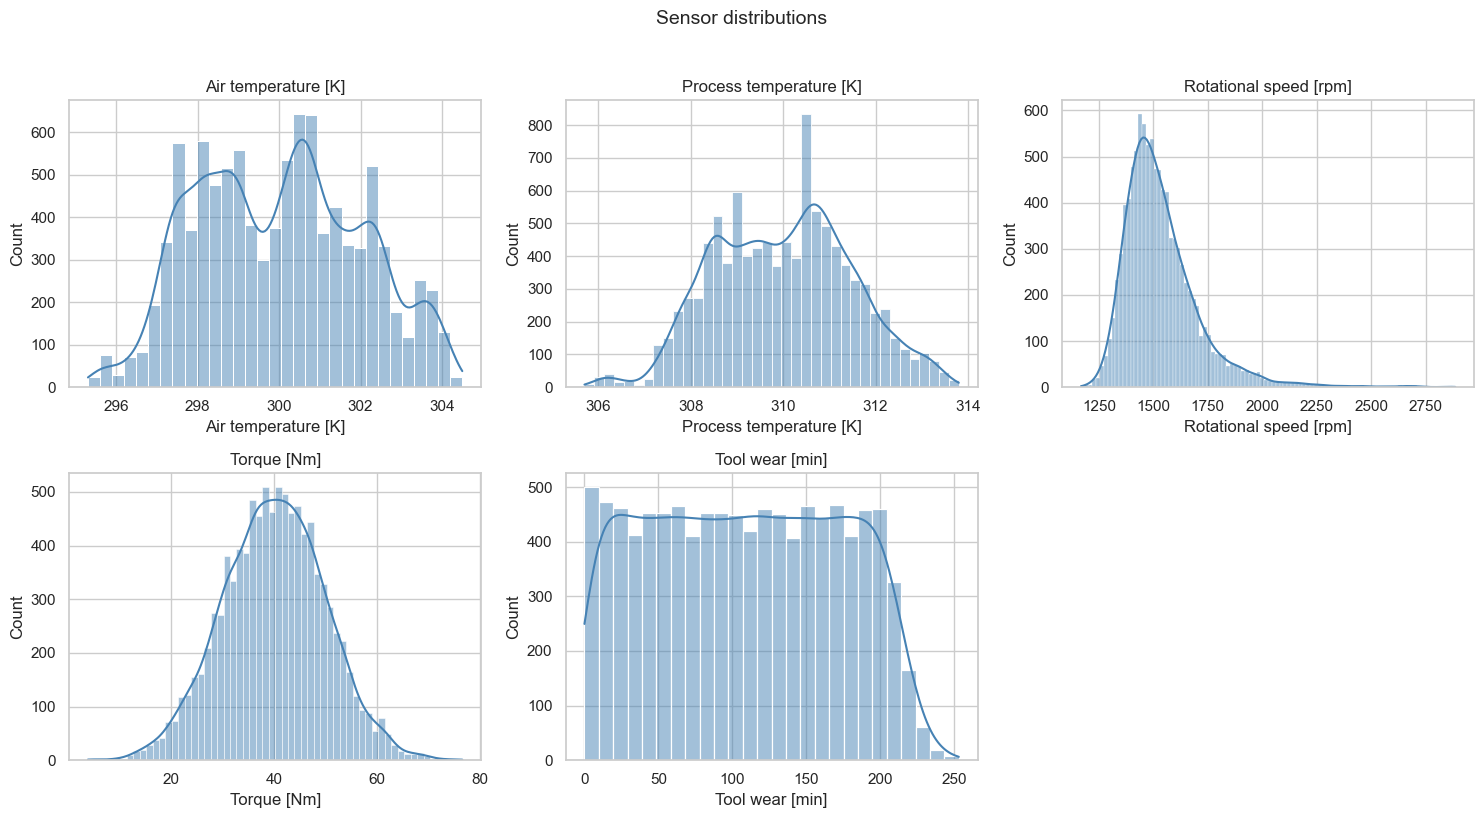

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(SENSOR_COLS):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
axes[-1].axis('off')
fig.suptitle('Sensor distributions', fontsize=14, y=1.02)
fig.tight_layout()
save_fig(fig, '01_sensor_histograms')
plt.show()


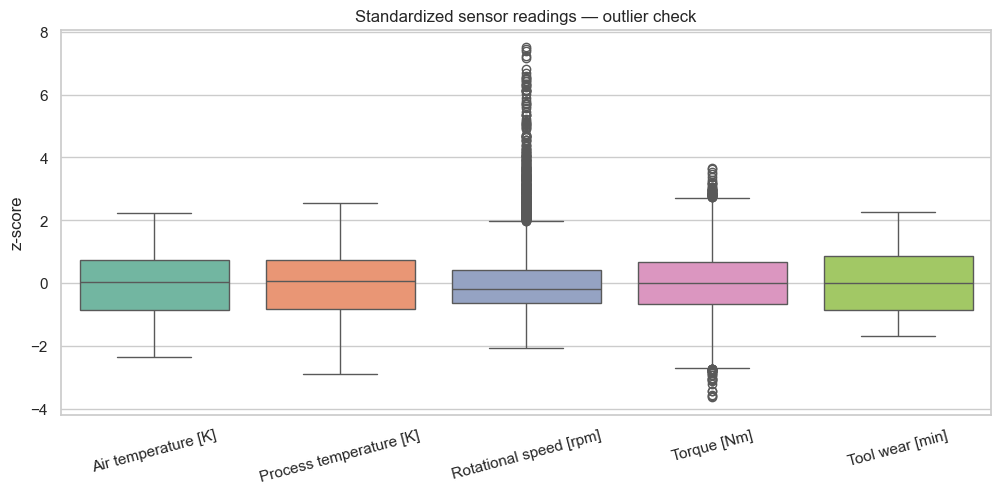

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
z = (df[SENSOR_COLS] - df[SENSOR_COLS].mean()) / df[SENSOR_COLS].std()
sns.boxplot(data=z, ax=ax, palette='Set2')
ax.set_title('Standardized sensor readings — outlier check')
ax.set_ylabel('z-score')
plt.xticks(rotation=15)
save_fig(fig, '02_sensor_boxplots')
plt.show()


## 5. Quality Type Distribution


      count   pct
Type             
L      6000  60.0
M      2997  30.0
H      1003  10.0


C:\Users\nawin\AppData\Local\Temp\ipykernel_28944\196258927.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Type', data=df, order=['L', 'M', 'H'], palette='viridis', ax=ax)


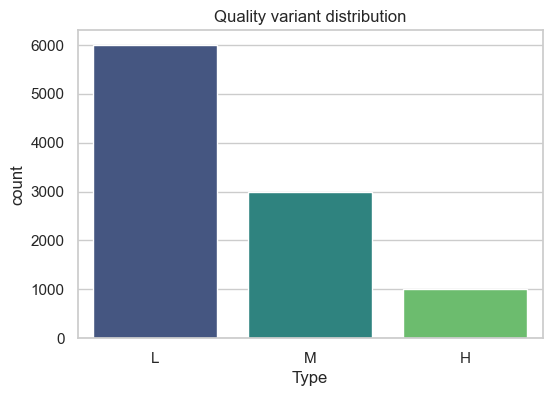

In [8]:
type_counts = df['Type'].value_counts()
type_pct = (type_counts / len(df) * 100).round(1)
print(pd.DataFrame({'count': type_counts, 'pct': type_pct}))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='Type', data=df, order=['L', 'M', 'H'], palette='viridis', ax=ax)
ax.set_title('Quality variant distribution')
save_fig(fig, '03_type_distribution')
plt.show()


## 6. Failure Rate Analysis


In [9]:
n = len(df)
n_fail = int(df['Machine failure'].sum())
fail_rate = n_fail / n * 100
print(f'Machine failures: {n_fail:,} / {n:,}  ({fail_rate:.2f}%)')
print(f'Healthy runs:     {n - n_fail:,} / {n:,}  ({100 - fail_rate:.2f}%)')


Machine failures: 339 / 10,000  (3.39%)
Healthy runs:     9,661 / 10,000  (96.61%)


     count  pct_of_failures  pct_of_all_records
HDF    115             33.9                1.15
OSF     98             28.9                0.98
PWF     95             28.0                0.95
TWF     46             13.6                0.46
RNF     19              5.6                0.19


C:\Users\nawin\AppData\Local\Temp\ipykernel_28944\329447127.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fail_breakdown.index, y=fail_breakdown.values, palette='Reds_r', ax=ax)


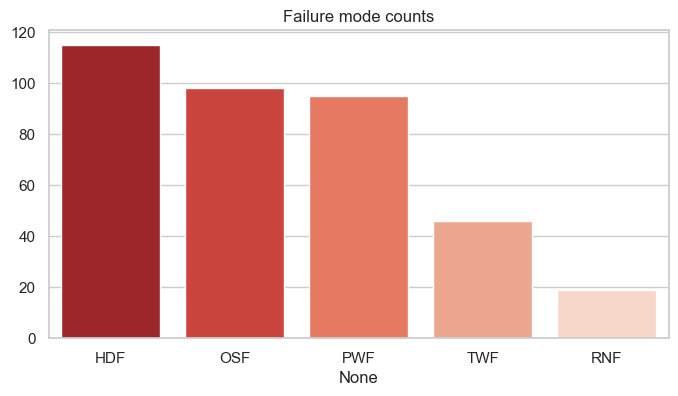

In [10]:
fail_breakdown = df[FAILURE_COLS].sum().sort_values(ascending=False)
fail_breakdown_pct = (fail_breakdown / n_fail * 100).round(1)
summary = pd.DataFrame({
    'count': fail_breakdown,
    'pct_of_failures': fail_breakdown_pct,
    'pct_of_all_records': (fail_breakdown / n * 100).round(2),
})
print(summary)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=fail_breakdown.index, y=fail_breakdown.values, palette='Reds_r', ax=ax)
ax.set_title('Failure mode counts')
save_fig(fig, '04_failure_mode_counts')
plt.show()


**Failure mode glossary:** TWF=Tool Wear · HDF=Heat Dissipation · PWF=Power · OSF=Overstrain · RNF=Random


In [11]:
df['n_failure_modes'] = df[FAILURE_COLS].sum(axis=1)
cooccur = df.loc[df['Machine failure'] == 1, 'n_failure_modes'].value_counts().sort_index()
print('Failure modes triggered per failed record:')
print(cooccur)


Failure modes triggered per failed record:
n_failure_modes
0      9
1    306
2     23
3      1
Name: count, dtype: int64


## 7. Bivariate — Sensor Distributions Split by Failure


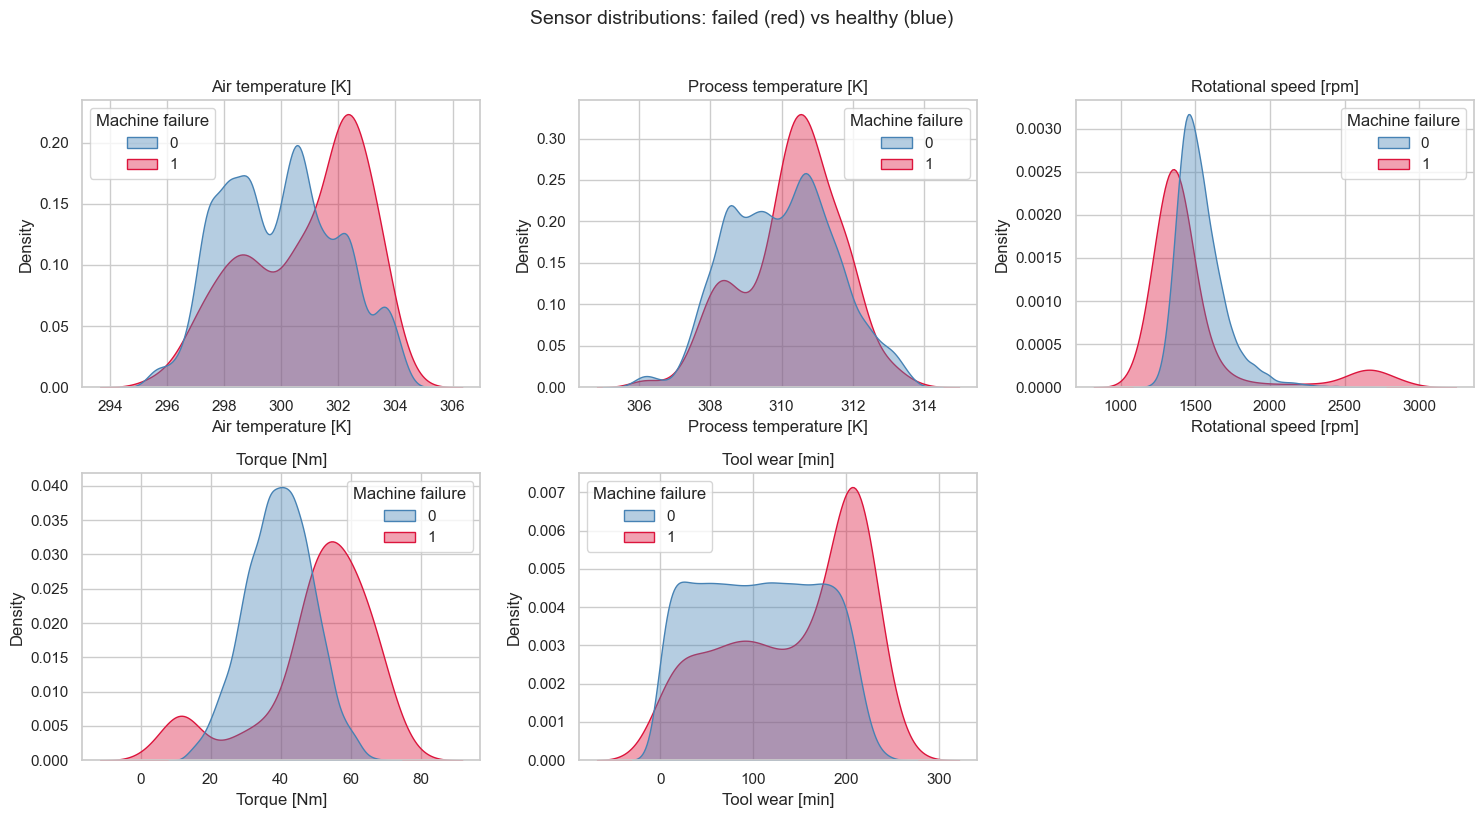

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(SENSOR_COLS):
    sns.kdeplot(data=df, x=col, hue='Machine failure', common_norm=False,
                fill=True, alpha=0.4, ax=axes[i], palette={0: 'steelblue', 1: 'crimson'})
    axes[i].set_title(col)
axes[-1].axis('off')
fig.suptitle('Sensor distributions: failed (red) vs healthy (blue)', fontsize=14, y=1.02)
fig.tight_layout()
save_fig(fig, '05_sensors_by_failure')
plt.show()


Look for **shifts** between distributions — bigger shift = stronger sensor signal.


## 8. Correlation Heatmap


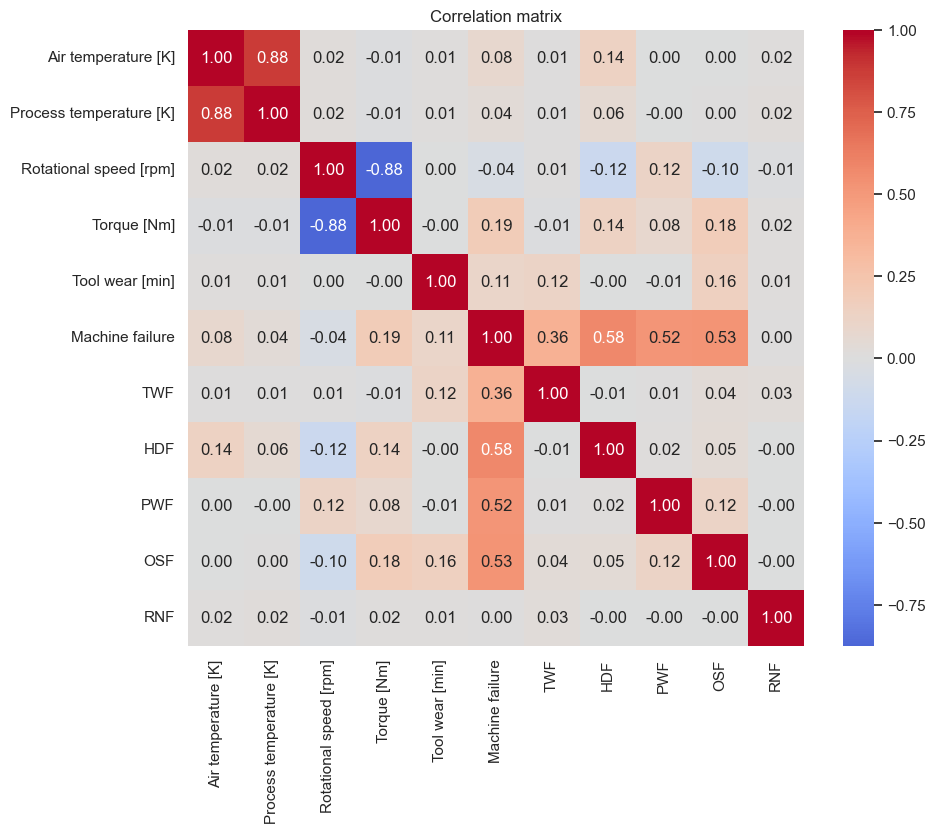

In [13]:
num_cols = SENSOR_COLS + ['Machine failure'] + FAILURE_COLS
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax)
ax.set_title('Correlation matrix')
save_fig(fig, '06_correlation_heatmap')
plt.show()


In [14]:
fail_corr = corr.loc[SENSOR_COLS, ['Machine failure'] + FAILURE_COLS].abs()
print('Strongest sensor signals per failure mode:')
for col in fail_corr.columns:
    top_sensor = fail_corr[col].idxmax()
    val = corr.loc[top_sensor, col]
    print(f'  {col:>16}  ↔  {top_sensor:<25}  r = {val:+.3f}')


Strongest sensor signals per failure mode:
   Machine failure  ↔  Torque [Nm]                r = +0.191
               TWF  ↔  Tool wear [min]            r = +0.116
               HDF  ↔  Torque [Nm]                r = +0.143
               PWF  ↔  Rotational speed [rpm]     r = +0.123
               OSF  ↔  Torque [Nm]                r = +0.183
               RNF  ↔  Process temperature [K]    r = +0.022


## 9. Operating Window — Torque × Rotational Speed


Classic AI4I pattern: OSF failures cluster in high-torque + low-rpm corner.


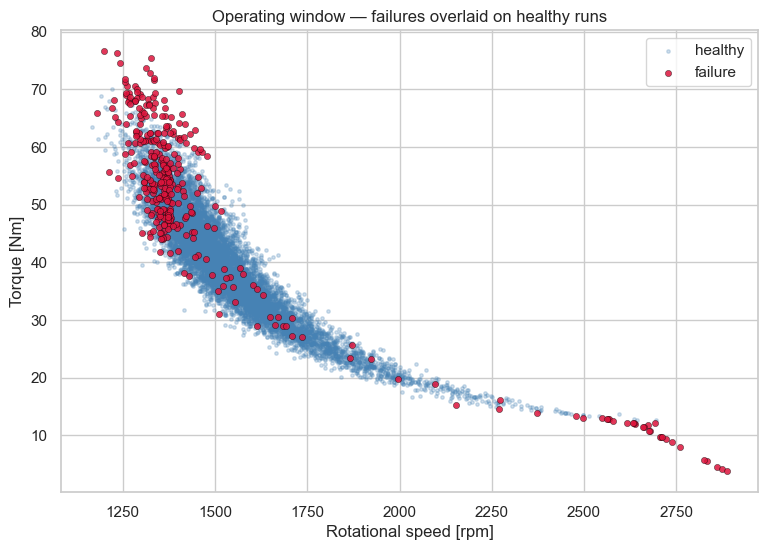

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
healthy = df[df['Machine failure'] == 0]
failed = df[df['Machine failure'] == 1]
ax.scatter(healthy['Rotational speed [rpm]'], healthy['Torque [Nm]'],
           s=6, alpha=0.25, color='steelblue', label='healthy')
ax.scatter(failed['Rotational speed [rpm]'], failed['Torque [Nm]'],
           s=20, alpha=0.85, color='crimson', label='failure', edgecolor='black', linewidth=0.3)
ax.set_xlabel('Rotational speed [rpm]')
ax.set_ylabel('Torque [Nm]')
ax.set_title('Operating window — failures overlaid on healthy runs')
ax.legend()
save_fig(fig, '07_operating_window')
plt.show()


## 10. Temperature Gap — Heat Dissipation Signature


C:\Users\nawin\AppData\Local\Temp\ipykernel_28944\844855718.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='HDF', y='Temp gap [K]', ax=axes[1], palette={'0': 'lightblue', '1': 'crimson'})


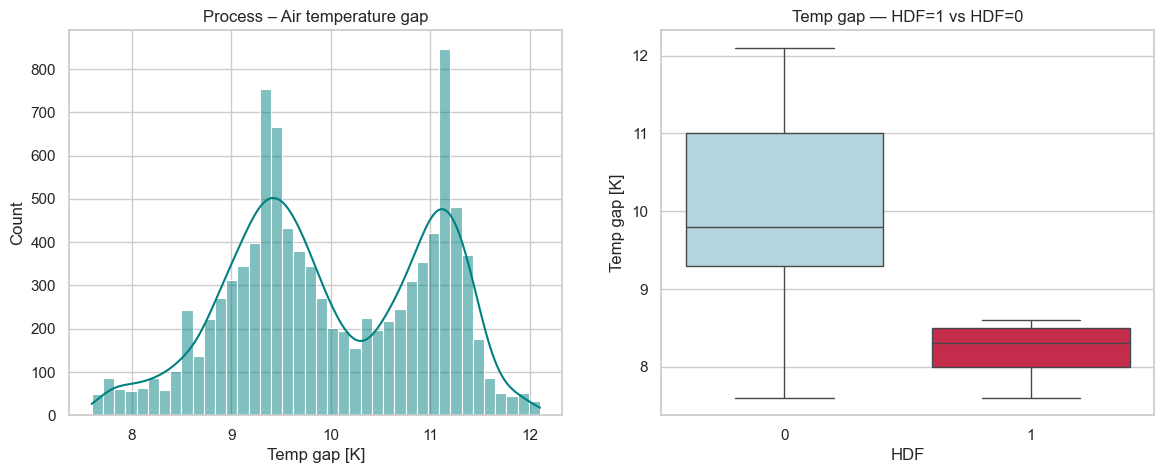

In [16]:
df['Temp gap [K]'] = df['Process temperature [K]'] - df['Air temperature [K]']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Temp gap [K]'], bins=40, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Process – Air temperature gap')
sns.boxplot(data=df, x='HDF', y='Temp gap [K]', ax=axes[1], palette={'0': 'lightblue', '1': 'crimson'})
axes[1].set_title('Temp gap — HDF=1 vs HDF=0')
save_fig(fig, '08_temperature_gap')
plt.show()

## 11. Failure Rate by Quality Type


         n  failures  failure_rate_pct
Type                                  
H     1003        21              2.09
L     6000       235              3.92
M     2997        83              2.77


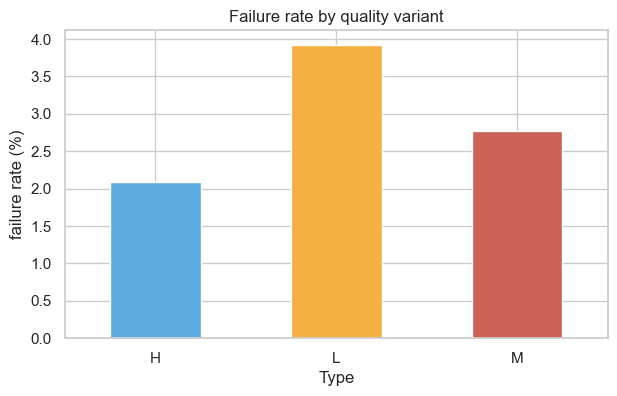

In [17]:
by_type = df.groupby('Type').agg(
    n=('UDI', 'count'),
    failures=('Machine failure', 'sum'),
)
by_type['failure_rate_pct'] = (by_type['failures'] / by_type['n'] * 100).round(2)
print(by_type)

fig, ax = plt.subplots(figsize=(7, 4))
by_type['failure_rate_pct'].plot(kind='bar', ax=ax, color=['#5dade2', '#f5b041', '#cd6155'])
ax.set_title('Failure rate by quality variant')
ax.set_ylabel('failure rate (%)')
plt.xticks(rotation=0)
save_fig(fig, '09_failure_rate_by_type')
plt.show()


## 12. Save Cleaned Dataset for the Dashboard


In [18]:
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

clean = df.copy()
clean = clean.rename(columns={
    'Air temperature [K]': 'air_temp_k',
    'Process temperature [K]': 'process_temp_k',
    'Rotational speed [rpm]': 'rotational_speed_rpm',
    'Torque [Nm]': 'torque_nm',
    'Tool wear [min]': 'tool_wear_min',
    'Machine failure': 'machine_failure',
    'Temp gap [K]': 'temp_gap_k',
    'Product ID': 'product_id',
})
clean.columns = [c.lower() for c in clean.columns]

out = DATA_PROCESSED / 'ai4i_clean.csv'
clean.to_csv(out, index=False)
print(f'Saved {len(clean):,} rows → {out}')
clean.head()


Saved 10,000 rows → C:\Project_DA\industrial-eda-dashboard\data\processed\ai4i_clean.csv


,udi,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,n_failure_modes,temp_gap_k
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,0,10.5
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,0,10.5
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,0,10.4
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,0,10.4
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,0,10.5


## 13. Key Findings
- Failure rate: 3.39% (339/10,000)
- Top mode: HDF (115, 33.9%)
- Strongest correlation: Torque ↔ Machine failure r=+0.19
- Highest-risk type: L (3.92%)
- Risk pocket: Torque > 60 Nm AND RPM < 1400 → 40.1% failure rate
